In [ ]:
import requests
import json
from skimage import io
import matplotlib.pyplot as plt

# Chave de API
api_key = 'GIFHBLrRgOlQZtNSF8psRyS8hmr6DrjHecd5IMiK'

# Faz a requisição GET para a API do APOD
url_apod = f'https://api.nasa.gov/planetary/apod?api_key={api_key}'
response_apod = requests.get(url_apod)

# Verifica se a requisição foi bem-sucedida
if response_apod.status_code == 200:
    data_apod = response_apod.json()
    print(f"Copyright: {data_apod.get('copyright', 'Não disponível')}")
    print(f"Explanation: {data_apod['explanation']}")

    # Carrega a imagem
    img_apod = io.imread(data_apod['hdurl'])

    # Plota a imagem
    plt.imshow(img_apod)
    plt.title(data_apod['title'])
    plt.show()

    # Imprime os limites de requisição
    print(f"X-RateLimit-Limit: {response_apod.headers['X-RateLimit-Limit']}")
    print(f"X-RateLimit-Remaining: {response_apod.headers['X-RateLimit-Remaining']}")
else:
    print(f"Erro: {response_apod.status_code}")

# Faz a requisição GET para a API do rover Curiosity
url_curiosity = f'https://api.nasa.gov/mars-photos/api/v1/manifests/Curiosity?api_key={api_key}'
response_curiosity = requests.get(url_curiosity)

if response_curiosity.status_code == 200:
    data_curiosity = response_curiosity.json()
    photo_manifest = data_curiosity['photo_manifest']
    max_sol = photo_manifest['max_sol']
    max_date = photo_manifest['max_date']
    print(f"max_sol: {max_sol}")
    print(f"max_date: {max_date}")

    # Faz a requisição GET para a API das imagens do rover Curiosity
    url_photos = f'https://api.nasa.gov/mars-photos/api/v1/rovers/Curiosity/photos?sol={max_sol}&api_key={api_key}'
    response_photos = requests.get(url_photos)

    if response_photos.status_code == 200:
        data_photos = response_photos.json()
        photos = data_photos['photos']

        # Plota as imagens das câmeras NAVCAM, FHAZ e RHAZ
        for photo in photos:
            camera_name = photo['camera']['name']
            if camera_name in ['NAVCAM', 'FHAZ', 'RHAZ']:
                img_url = photo['img_src']
                img = io.imread(img_url)
                plt.imshow(img)
                plt.title(f"{camera_name} - {photo['id']}")
                plt.show()
    else:
        print(f"Erro: {response_photos.status_code}")
else:
    print(f"Erro: {response_curiosity.status_code}")

In [1]:
import requests
import json
from skimage import io
import matplotlib.pyplot as plt

In [2]:
# Creat o arquivo key.json
with open('key.json', 'w') as f:
    f.write('API_KEY=GIFHBLrRgOlQZtNSF8psRyS8hmr6DrjHecd5IMiK')

In [3]:

# Chave de API
api_key = 'GIFHBLrRgOlQZtNSF8psRyS8hmr6DrjHecd5IMiK'

In [4]:
# Faz a requisição GET para a API do APOD
url_apod = f'https://api.nasa.gov/planetary/apod?api_key={api_key}'
response_apod = requests.get(url_apod)

In [5]:
# Verifica se a requisição foi bem-sucedida
if response_apod.status_code == 200:
    data_apod = response_apod.json()
    print(f"Copyright: {data_apod.get('copyright', 'Não disponível')}")
    print(f"Explanation: {data_apod['explanation']}")

Copyright: When the Moon
Explanation: When the Moon is at its first quarter phase, the Sun rises along the Montes Caucasus as seen from the lunar surface. The lunar mountain range casts the magnificent, spire-like shadows in this telescopic view from planet Earth, looking along the lunar terminator or the boundary between lunar night and day. Named for Earth's own Caucasus Mountains, the rugged lunar Montes Caucasus peaks, up to 6 kilometers high, are located between the smooth Mare Imbrium to the west and Mare Serenitatis to the east. Still mostly in shadow in this first quarter lunarscape, at the left (west) impact craters reflect the light of the rising Sun along their outer, eastern crater walls.


In [6]:

    # Carrega a imagem
    img_apod = io.imread(data_apod['hdurl'])

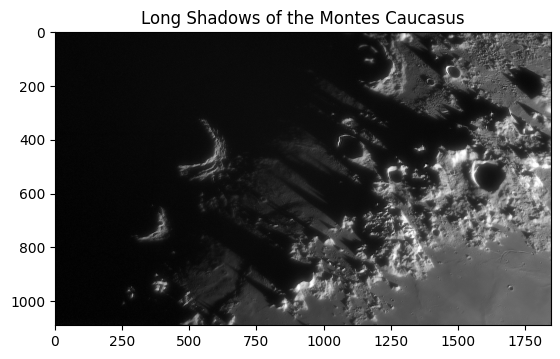

In [8]:

    # Plota a imagem
    plt.imshow(img_apod)
    plt.title(data_apod['title'])
    plt.show()


In [12]:
    # Imprime os limites de requisição
    print(f"X-RateLimit-Limit: {response_apod.headers['X-RateLimit-Limit']}")
    print(f"X-RateLimit-Remaining: {response_apod.headers['X-RateLimit-Remaining']}")

X-RateLimit-Limit: 4000
X-RateLimit-Remaining: 3999


In [11]:
# Faz a requisição GET para a API do rover Curiosity
url_curiosity = f'https://api.nasa.gov/mars-photos/api/v1/manifests/Curiosity?api_key={api_key}'
response_curiosity = requests.get(url_curiosity)

if response_curiosity.status_code == 200:
    data_curiosity = response_curiosity.json()
    photo_manifest = data_curiosity['photo_manifest']
    max_sol = photo_manifest['max_sol']
    max_date = photo_manifest['max_date']
    print(f"max_sol: {max_sol}")
    print(f"max_date: {max_date}")

In [18]:
# Ensure max_sol is defined. If not, fetch it from the Curiosity manifest.
if 'max_sol' not in globals():
    url_curiosity = f'https://api.nasa.gov/mars-photos/api/v1/manifests/Curiosity?api_key={api_key}'
    response_curiosity = requests.get(url_curiosity)
    if response_curiosity.status_code == 200:
        data_curiosity = response_curiosity.json()
        photo_manifest = data_curiosity['photo_manifest']
        max_sol = photo_manifest['max_sol']
    else:
        max_sol = None # Set to None to prevent further NameError if manifest fetch fails
        print(f"Erro ao obter o manifesto do Curiosity: {response_curiosity.status_code}")

if max_sol is not None:
    # Faz a requisição GET para a API das imagens do rover Curiosity
    url_photos = f'https://api.nasa.gov/mars-photos/api/v1/rovers/Curiosity/photos?sol={max_sol}&api_key={api_key}'
    response_photos = requests.get(url_photos)

    if response_photos.status_code == 200:
        data_photos = response_photos.json()
        photos = data_photos['photos']
    else:
        print(f"Erro ao obter as fotos do Curiosity: {response_photos.status_code}")
else:
    print("max_sol não foi definido, não foi possível buscar as fotos do Curiosity.")

max_sol não foi definido, não foi possível buscar as fotos do Curiosity.


In [17]:
if 'photos' in globals() and photos:
    # Plota as imagens das câmeras NAVCAM, FHAZ e RHAZ
    for photo in photos:
        camera_name = photo['camera']['name']
        if camera_name in ['NAVCAM', 'FHAZ', 'RHAZ']:
            img_url = photo['img_src']
            img = io.imread(img_url)
            plt.imshow(img)
            plt.title(f"{camera_name} - {photo['id']}")
            plt.show()